# Kalshi World Cup orderbook/trade EDA

EDA for short-horizon in-match price moves using local Kalshi World Cup orderbook snapshots and historical trade prints. This is hypothesis-finding, not a backtest.

In [1]:
from pathlib import Path
import gzip, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
FIG = ROOT / "reports/figures/kalshi_worldcup"
FIG.mkdir(parents=True, exist_ok=True)
NARRATION = ROOT / "data/raw/sports_narration/manual_match_events.csv"
print(ROOT)

def parse_match_minute(value):
    s = str(value)
    if s.isdigit():
        return int(s)
    if "+" in s and s.split("+")[0].isdigit():
        return sum(int(x) for x in s.split("+") if x.isdigit())
    return np.nan

def load_manual_events():
    if not NARRATION.exists():
        return pd.DataFrame(columns=["event_ticker", "ts", "minute", "event_type", "team", "text", "source"])
    ev = pd.read_csv(NARRATION)
    ev["ts"] = pd.to_datetime(ev["ts"], utc=True, errors="coerce")
    ev["minute_num"] = ev["minute"].apply(parse_match_minute)
    return ev

def match_bounds(event, events_manual=None):
    ev = load_manual_events() if events_manual is None else events_manual
    ev = ev[ev["event_ticker"].eq(event)].dropna(subset=["ts"])
    starts = ev[ev["event_type"].eq("match_start")]
    if not starts.empty:
        start = starts["ts"].min()
    else:
        mins = ev.dropna(subset=["minute_num"])
        start = None if mins.empty else (mins["ts"] - pd.to_timedelta(mins["minute_num"], unit="m")).min()
    ft = ev[ev["event_type"].eq("fulltime")]
    end = None if ft.empty else ft["ts"].max()
    return start, end

def mark_match_bounds(ax, event, events_manual=None):
    start, end = match_bounds(event, events_manual)
    if pd.notna(start):
        ax.axvline(start, color="black", ls="--", lw=1, alpha=.7)
        ax.text(start, ax.get_ylim()[0], "match start", rotation=90, va="bottom", ha="right", fontsize=8)
    if pd.notna(end):
        ax.axvline(end, color="black", ls="--", lw=1, alpha=.7)
        ax.text(end, ax.get_ylim()[0], "match end", rotation=90, va="bottom", ha="left", fontsize=8)
    if pd.notna(start) and pd.notna(end):
        ax.axvspan(start, end, color="black", alpha=.03)


EVENT_COLORS = {"goal": "green", "own_goal": "limegreen", "yellow_card": "gold", "substitution": "tab:blue", "halftime": "gray", "fulltime": "black", "match_start": "black"}


/Users/zhangxincheng/Documents/toyDAG


## 1. Load all raw orderbooks and trades

Read file contents, not filenames; the raw capture files use mixed naming styles.

In [2]:
def read_jsonl(path):
    opener = gzip.open if path.suffix == ".gz" else open
    with opener(path, "rt") as f:
        return [json.loads(line) for line in f if line.strip()]

ob_rows = []
for path in sorted((ROOT / "data/raw/kalshi/orderbooks").glob("*.jsonl")):
    for row in read_jsonl(path):
        row["source_file"] = path.name
        ob_rows.append(row)

tr_rows = []
for path in sorted((ROOT / "data/raw/kalshi/trades").glob("*.jsonl*")):
    for row in read_jsonl(path):
        row["source_file"] = path.name
        tr_rows.append(row)

raw_ob = pd.DataFrame(ob_rows)
raw_tr = pd.DataFrame(tr_rows)
print(f"orderbook rows: {len(raw_ob):,} across {raw_ob['ticker'].nunique()} tickers")
print(f"trade rows:     {len(raw_tr):,} across {raw_tr['ticker'].nunique()} tickers")
raw_ob.head(2)

orderbook rows: 5,520 across 24 tickers
trade rows:     952,003 across 21 tickers


,event_ticker,no_ask,no_asks_top10,no_bid,no_bids_top10,no_spread,raw,status,subtitle,ticker,title,ts,yes_ask,yes_asks_top10,yes_bid,yes_bids_top10,yes_spread,source_file,event,expiration_value,result
0,KXWCGAME-26JUN17ENGCRO,0.19,"[{'price': 0.19, 'quantity': 1491386.4}, {'pri...",0.18,"[{'price': 0.18, 'quantity': 1207010.41}, {'pr...",0.01,"{'orderbook_fp': {'no_dollars': [['0.0100', '4...",active,England,KXWCGAME-26JUN17ENGCRO-ENG,England vs Croatia Winner?,2026-06-17T21:27:24.185143Z,0.82,"[{'price': 0.82, 'quantity': 1207010.41}, {'pr...",0.81,"[{'price': 0.81, 'quantity': 1491386.4}, {'pri...",0.01,kxwcgame-26jun17engcro_orderbooks.jsonl,NaN,NaN,NaN
1,KXWCGAME-26JUN17ENGCRO,0.97,"[{'price': 0.97, 'quantity': 391269.03}, {'pri...",0.96,"[{'price': 0.96, 'quantity': 499060.63}, {'pri...",0.01,"{'orderbook_fp': {'no_dollars': [['0.0100', '6...",active,Croatia,KXWCGAME-26JUN17ENGCRO-CRO,England vs Croatia Winner?,2026-06-17T21:27:24.851510Z,0.04,"[{'price': 0.04, 'quantity': 499060.63}, {'pri...",0.03,"[{'price': 0.03, 'quantity': 391269.03}, {'pri...",0.01,kxwcgame-26jun17engcro_orderbooks.jsonl,NaN,NaN,NaN


## 2. Normalize YES-view orderbooks and trades

YES bid is direct YES bid. YES ask is economically `1 - best NO bid`. Trade prices are already represented as YES prices in Kalshi's historical trade payload.

In [3]:
def event_from_ticker(s):
    return s.astype(str).str.rsplit("-", n=1).str[0]

def outcome_from_ticker(s):
    return s.astype(str).str.rsplit("-", n=1).str[-1]

def depth(levels, n=10):
    if not isinstance(levels, list):
        return 0.0
    return float(sum(float(x.get("quantity") or 0) for x in levels[:n]))

def first_price(levels):
    if isinstance(levels, list) and levels:
        return float(levels[0].get("price") or np.nan)
    return np.nan

ob = raw_ob.copy()
ob["ts"] = pd.to_datetime(ob["ts"], utc=True)
ob["event"] = ob.get("event_ticker", event_from_ticker(ob["ticker"])).fillna(event_from_ticker(ob["ticker"]))
ob["outcome"] = outcome_from_ticker(ob["ticker"])
ob["ts_bucket"] = ob["ts"].dt.round("30s")
for c in ["yes_bid", "yes_ask", "no_bid", "no_ask"]:
    ob[c] = pd.to_numeric(ob[c], errors="coerce")
ob["derived_yes_ask"] = 1 - ob["no_bid"]
ob["derived_no_ask"] = 1 - ob["yes_bid"]
ob["yes_mid"] = (ob["yes_bid"] + ob["derived_yes_ask"]) / 2
ob["spread"] = ob["derived_yes_ask"] - ob["yes_bid"]
ob["spread_pct"] = ob["spread"] / ob["yes_mid"].replace(0, np.nan)

for n in (1, 5, 10):
    ob[f"buy_depth_{n}"] = ob["yes_bids_top10"].apply(lambda x, n=n: depth(x, n))
    ob[f"sell_depth_{n}"] = ob["no_bids_top10"].apply(lambda x, n=n: depth(x, n))  # NO bids are YES asks
    denom = ob[f"buy_depth_{n}"] + ob[f"sell_depth_{n}"]
    ob[f"imbalance_{n}"] = ob[f"buy_depth_{n}"] / denom.replace(0, np.nan)
    ob[f"centered_imbalance_{n}"] = ob[f"imbalance_{n}"] - 0.5

checks = pd.Series({
    "yes_ask_equals_1_minus_no_bid_bad_rows": int((ob["yes_ask"].sub(ob["derived_yes_ask"]).abs() > 1e-9).sum()),
    "no_ask_equals_1_minus_yes_bid_bad_rows": int((ob["no_ask"].sub(ob["derived_no_ask"]).abs() > 1e-9).sum()),
    "bad_top_yes_ask_from_no_bid_rows": int(((ob["yes_asks_top10"].apply(first_price) - (1 - ob["no_bids_top10"].apply(first_price))).abs() > 1e-9).sum()),
})
print(checks.to_string())

tr = raw_tr.copy()
tr["ts"] = pd.to_datetime(tr["created_time"], utc=True)
tr["event"] = event_from_ticker(tr["ticker"])
tr["outcome"] = outcome_from_ticker(tr["ticker"])
tr["yes_price"] = pd.to_numeric(tr["yes_price_dollars"], errors="coerce")
tr["no_price"] = pd.to_numeric(tr["no_price_dollars"], errors="coerce")
tr["count"] = pd.to_numeric(tr["count_fp"], errors="coerce").fillna(0)
tr["aggressive_yes_volume"] = np.where(tr["taker_outcome_side"].eq("yes"), tr["count"], 0.0)
tr["aggressive_no_volume"] = np.where(tr["taker_outcome_side"].eq("no"), tr["count"], 0.0)

# Only use trades from the captured orderbook/match window for feature alignment; this removes old pre-match prints.
windows = ob.groupby("event")["ts"].agg(["min", "max"])
tr = tr.join(windows, on="event")
tr_window = tr[tr["ts"].between(tr["min"], tr["max"] + pd.Timedelta(minutes=2), inclusive="both")].drop(columns=["min", "max"])
print(f"window-filtered trades: {len(tr_window):,} / {len(tr):,}")
ob[["event", "outcome", "ts", "yes_bid", "derived_yes_ask", "yes_mid", "imbalance_10"]].head()

yes_ask_equals_1_minus_no_bid_bad_rows    0
no_ask_equals_1_minus_yes_bid_bad_rows    0
bad_top_yes_ask_from_no_bid_rows          0


window-filtered trades: 769,440 / 952,003


,event,outcome,ts,yes_bid,derived_yes_ask,yes_mid,imbalance_10
0,KXWCGAME-26JUN17ENGCRO,ENG,2026-06-17 21:27:24.185143+00:00,0.81,0.82,0.815,0.168205
1,KXWCGAME-26JUN17ENGCRO,CRO,2026-06-17 21:27:24.851510+00:00,0.03,0.04,0.035,0.559934
2,KXWCGAME-26JUN17ENGCRO,TIE,2026-06-17 21:27:25.507457+00:00,0.14,0.15,0.145,0.531303
3,KXWCGAME-26JUN17ENGCRO,ENG,2026-06-17 21:27:56.802795+00:00,0.80,0.81,0.805,0.028945
4,KXWCGAME-26JUN17ENGCRO,CRO,2026-06-17 21:27:57.480493+00:00,0.03,0.04,0.035,0.663085


## 3. Prediction targets and microstructure features

In [4]:
def add_asof_value(base, value_col, minutes, out_col=None):
    out = []
    out_col = out_col or f"{value_col}_fwd_{minutes}m"
    for ticker, g in base.sort_values("ts").groupby("ticker", sort=False):
        right = g[["ts", value_col]].rename(columns={"ts":"target_ts", value_col:out_col}).sort_values("target_ts")
        left = g.assign(target_ts=g["ts"] + pd.Timedelta(minutes=minutes)).sort_values("target_ts")
        j = pd.merge_asof(left, right, on="target_ts", direction="nearest", tolerance=pd.Timedelta(seconds=45))
        out.append(j.drop(columns="target_ts"))
    return pd.concat(out, ignore_index=True)

features = ob.sort_values(["ticker", "ts"]).copy()
for h in (1, 5, 15, 30, 60):
    features = add_asof_value(features, "yes_mid", h, f"mid_fwd_{h}m")
    features[f"ret_{h}m"] = features[f"mid_fwd_{h}m"] - features["yes_mid"]
    features[f"up_{h}m"] = features[f"ret_{h}m"] > 0
features["large_move_5m"] = features["ret_5m"].abs() >= 0.02

# market-normalized pressure and odds sums. Books are captured sequentially, so align outcomes by 30s bucket.
snapshot = features.sort_values("ts").groupby(["event", "ts_bucket", "outcome"], as_index=False).last()
sums = snapshot.groupby(["event", "ts_bucket"]).agg(
    sum_mid=("yes_mid", "sum"),
    sum_bid=("yes_bid", "sum"),
    sum_ask=("derived_yes_ask", "sum"),
    total_buy_depth_1=("buy_depth_1", "sum"),
    total_buy_depth_5=("buy_depth_5", "sum"),
    total_buy_depth_10=("buy_depth_10", "sum"),
).reset_index()
features = features.merge(sums, on=["event", "ts_bucket"], how="left")
features["outcome_mid_share"] = features["yes_mid"] / features["sum_mid"].replace(0, np.nan)
for n in (1, 5, 10):
    features[f"outcome_depth_share_{n}"] = features[f"buy_depth_{n}"] / features[f"total_buy_depth_{n}"].replace(0, np.nan)
    features[f"excess_pressure_{n}"] = features[f"outcome_depth_share_{n}"] - features["outcome_mid_share"]
features = features.drop(columns=["total_buy_depth_1", "total_buy_depth_5", "total_buy_depth_10"])

# lagged price/pressure changes
for m in (1, 5):
    lagged = []
    for ticker, g in features.sort_values("ts").groupby("ticker", sort=False):
        right = g[["ts", "yes_mid", "excess_pressure_10"]].rename(columns={"ts":"lag_ts", "yes_mid":f"mid_lag_{m}m", "excess_pressure_10":f"pressure_lag_{m}m"})
        left = g.assign(lag_ts=g["ts"] - pd.Timedelta(minutes=m)).sort_values("lag_ts")
        lagged.append(pd.merge_asof(left, right.sort_values("lag_ts"), on="lag_ts", direction="nearest", tolerance=pd.Timedelta(seconds=45)).drop(columns="lag_ts"))
    features = pd.concat(lagged, ignore_index=True)
    features[f"lagged_mid_return_{m}m"] = features["yes_mid"] - features[f"mid_lag_{m}m"]
    features[f"pressure_change_{m}m"] = features["excess_pressure_10"] - features[f"pressure_lag_{m}m"]

# rolling trade features merged to snapshots
rolls = []
for ticker, tt in tr_window.sort_values("ts").groupby("ticker", sort=False):
    x = tt.set_index("ts")[["count", "aggressive_yes_volume", "aggressive_no_volume"]].sort_index()
    r = pd.DataFrame(index=x.index)
    for w in ("1min", "5min"):
        suf = "1m" if w == "1min" else "5m"
        r[f"volume_{suf}"] = x["count"].rolling(w).sum()
        r[f"trade_count_{suf}"] = x["count"].rolling(w).count()
        r[f"aggressive_yes_volume_{suf}"] = x["aggressive_yes_volume"].rolling(w).sum()
        r[f"aggressive_no_volume_{suf}"] = x["aggressive_no_volume"].rolling(w).sum()
    r = r.reset_index().assign(ticker=ticker)
    rolls.append(r)
roll = pd.concat(rolls, ignore_index=True) if rolls else pd.DataFrame(columns=["ts", "ticker"])

merged = []
for ticker, g in features.sort_values("ts").groupby("ticker", sort=False):
    rr = roll[roll["ticker"].eq(ticker)].sort_values("ts")
    if rr.empty:
        merged.append(g)
    else:
        merged.append(pd.merge_asof(g.sort_values("ts"), rr.drop(columns="ticker"), on="ts", direction="backward", tolerance=pd.Timedelta(minutes=5)))
features = pd.concat(merged, ignore_index=True)
for c in [c for c in features.columns if c.startswith(("volume_", "trade_count_", "aggressive_"))]:
    features[c] = features[c].fillna(0)
features["avg_trade_size_1m"] = features["volume_1m"] / features["trade_count_1m"].replace(0, np.nan)
features["aggressive_yes_share_1m"] = features["aggressive_yes_volume_1m"] / (features["aggressive_yes_volume_1m"] + features["aggressive_no_volume_1m"]).replace(0, np.nan)
features["time_to_close_minutes"] = (features.groupby("event")["ts"].transform("max") - features["ts"]).dt.total_seconds() / 60
features["sum_mid_deviation_from_1"] = features["sum_mid"] - 1

assert checks.eq(0).all(), checks.to_dict()
assert features[["ret_1m", "ret_5m", "ret_15m", "ret_30m", "ret_60m"]].notna().any().all()
assert features["event"].nunique() == 8
print(features.shape)
features[["event", "outcome", "ts", "yes_mid", "ret_5m", "volume_1m", "imbalance_10", "excess_pressure_10"]].head()

(5520, 86)


,event,outcome,ts,yes_mid,ret_5m,volume_1m,imbalance_10,excess_pressure_10
0,KXWCGAME-26JUN16IRQNOR,IRQ,2026-06-16 21:32:58.604151+00:00,0.075,0.0,0.00,0.191532,0.442061
1,KXWCGAME-26JUN16IRQNOR,IRQ,2026-06-16 21:33:28.607743+00:00,0.075,0.0,11881.60,0.191471,0.366202
2,KXWCGAME-26JUN16IRQNOR,IRQ,2026-06-16 21:33:58.614275+00:00,0.075,0.0,25052.36,0.191463,0.370172
3,KXWCGAME-26JUN16IRQNOR,IRQ,2026-06-16 21:34:28.617413+00:00,0.075,0.0,21073.89,0.191177,0.370297
4,KXWCGAME-26JUN16IRQNOR,IRQ,2026-06-16 21:34:58.618678+00:00,0.075,0.0,20003.51,0.190919,0.370252


## 4. Trading activity intensity

,total_volume,total_trades,peak_1m_volume
event,,,
KXWCGAME-26JUN16ARGDZA,33189475.9,207279,837425.3
KXWCGAME-26JUN16IRQNOR,29511602.0,129793,1063863.7
KXWCGAME-26JUN17UZBCOL,25202603.0,100409,1400506.5
KXWCGAME-26JUN17GHAPAN,23209107.7,121530,1060208.6
KXWCGAME-26JUN18CZERSA,13506728.3,93001,410324.8
KXWCGAME-26JUN18SUIBIH,12759736.2,76989,620269.3
KXWCGAME-26JUN17ENGCRO,8896310.3,40439,1070900.8


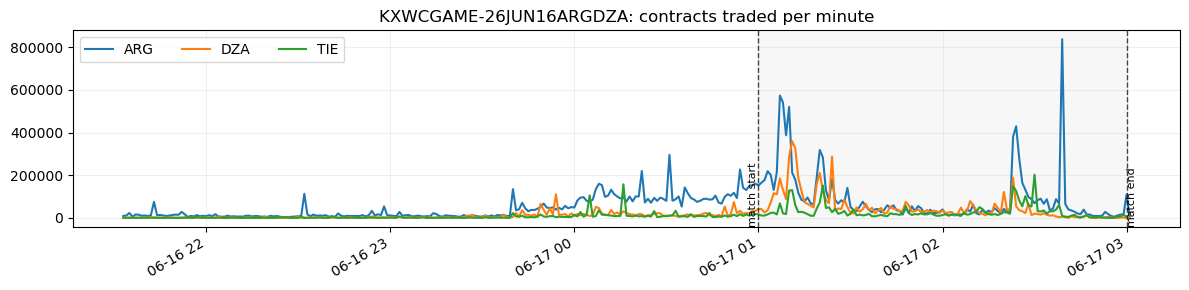

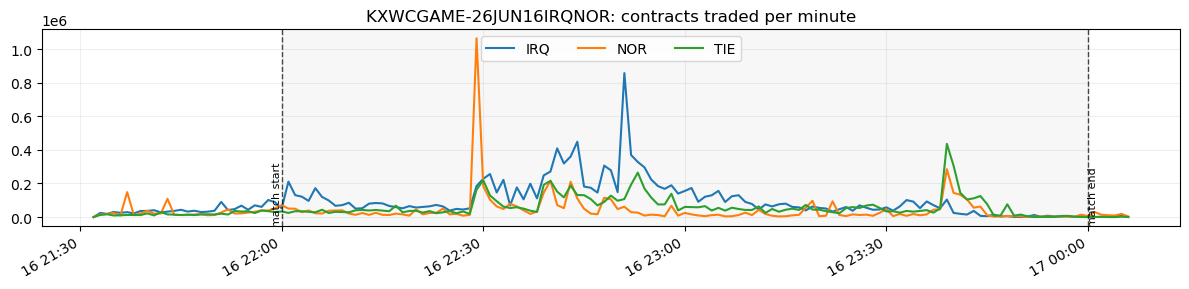

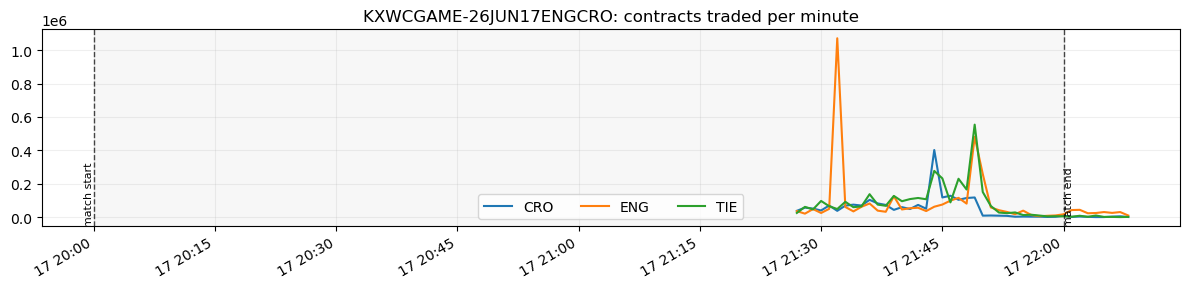

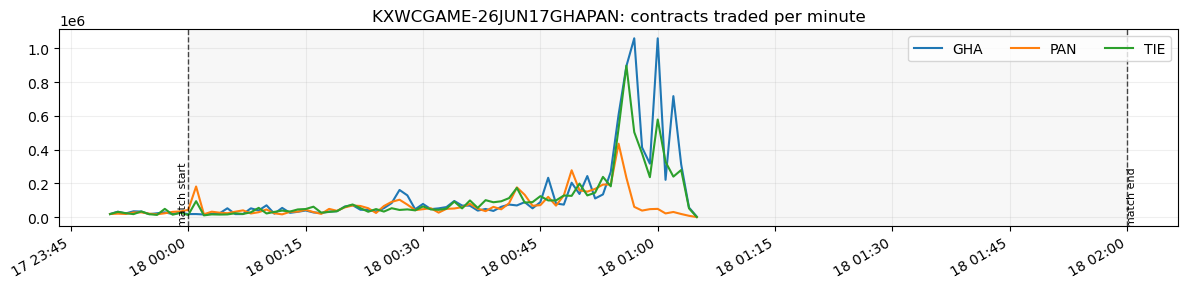

In [5]:
activity = (tr_window.set_index("ts")
    .groupby(["event", "outcome"])
    .resample("1min")["count"]
    .agg(volume="sum", trade_count="count")
    .reset_index())
activity["cum_volume"] = activity.sort_values("ts").groupby(["event", "outcome"])["volume"].cumsum()
activity_summary = activity.groupby("event").agg(total_volume=("volume", "sum"), total_trades=("trade_count", "sum"), peak_1m_volume=("volume", "max")).sort_values("total_volume", ascending=False)
display(activity_summary.round(1))

for event in sorted(features["event"].unique())[:4]:
    fig, ax = plt.subplots(figsize=(12, 3))
    for outcome, g in activity[activity["event"].eq(event)].groupby("outcome"):
        ax.plot(g["ts"], g["volume"], label=outcome)
    ax.set_title(f"{event}: contracts traded per minute")
    mark_match_bounds(ax, event)
    ax.grid(alpha=.2); ax.legend(ncol=3)
    fig.autofmt_xdate(); fig.tight_layout()
    fig.savefig(FIG / f"volume_{event}.png", dpi=160)
    plt.show()

## 5. Three-outcome market consistency

sum_bid             sum_mid             sum_ask             buy_all_edge             sell_all_edge            
                          mean   min   max    mean  min    max    mean   min   max         mean   min   max          mean   min   max
event                                                                                                                                
KXWCGAME-26JUN16ARGDZA  0.9617  0.17  1.12  0.9089  0.0  1.135  0.9241  0.02  1.15       0.0759 -0.15  0.98       -0.0383 -0.83  0.12
KXWCGAME-26JUN16IRQNOR  0.9907  0.94  1.01  0.8618  0.0  1.075  0.8779  0.02  1.14       0.1221 -0.14  0.98       -0.0093 -0.06  0.01
KXWCGAME-26JUN17ENGCRO  0.9496  0.00  1.01  0.5314  0.0  1.025  0.5482  0.00  1.04       0.4518 -0.04  1.00       -0.0504 -1.00  0.01
KXWCGAME-26JUN17GHAPAN  0.9469  0.00  1.00  0.9050  0.0  1.015  0.9202  0.01  1.03       0.0798 -0.03  0.99       -0.0531 -1.00  0.00
KXWCGAME-26JUN17PORCOD  0.9815  0.00  1.03  0.9773  0.0  1.055  0.9925  0.00  1.08       0.0075 -0.08  1.00       -0.0185 -1.00  0.03
KXWCGAME-26JUN17UZBCOL  0.9405  0.00  1.01  0.8588  0.0  1.020  0.8752  0.01  1.04       0.1248 -0.04  0.99       -0.0595 -1.00  0.01
KXWCGAME-26JUN18CZERSA  0.9504  0.00  1.01  0.9000  0.0  1.025  0.9152  0.00  1.04       0.0848 -0.04  1.00       -0.0496 -1.00  0.01
KXWCGAME-26JUN18SUIBIH  0.9516  0.06  1.01  0.7450  0.0  1.025  0.7609  0.02  1.04       0.2391 -0.04  0.98       -0.0484 -0.94  0.01

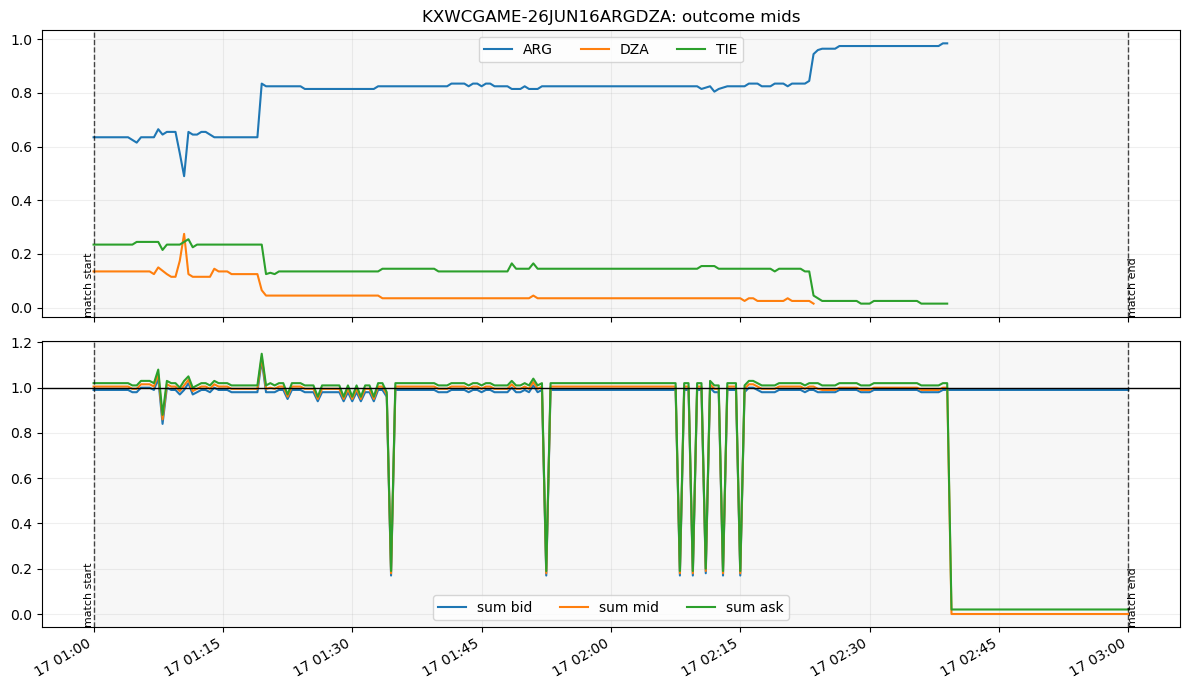

1m return correlations across outcomes:


outcome,ARG,BIH,COD,COL,CRO,CZE,DZA,ENG,GHA,IRQ,NOR,PAN,POR,RSA,SUI,TIE,UZB
outcome,,,,,,,,,,,,,,,,,
ARG,1.000,NaN,NaN,NaN,NaN,NaN,-0.825,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.490,NaN
BIH,NaN,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.942,0.905,NaN
COD,NaN,NaN,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.769,NaN,NaN,0.621,NaN
COL,NaN,NaN,NaN,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.980,-0.977
CRO,NaN,NaN,NaN,NaN,1.000,NaN,NaN,-0.352,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.306,NaN
CZE,NaN,NaN,NaN,NaN,NaN,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.720,NaN,-0.971,NaN
DZA,-0.825,NaN,NaN,NaN,NaN,NaN,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.313,NaN
ENG,NaN,NaN,NaN,NaN,-0.352,NaN,NaN,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.770,NaN
GHA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000,NaN,NaN,-0.418,NaN,NaN,NaN,-0.995,NaN


In [6]:
snapshot = features.sort_values("ts").groupby(["event", "ts_bucket", "outcome"], as_index=False).last()
odds = snapshot.groupby(["event", "ts_bucket"], as_index=False).agg(
    ts=("ts", "max"),
    sum_bid=("yes_bid", "sum"),
    sum_mid=("yes_mid", "sum"),
    sum_ask=("derived_yes_ask", "sum"),
).sort_values(["event", "ts_bucket"])
odds["buy_all_edge"] = 1 - odds["sum_ask"]
odds["sell_all_edge"] = odds["sum_bid"] - 1
odds_summary = odds.groupby("event")[["sum_bid", "sum_mid", "sum_ask", "buy_all_edge", "sell_all_edge"]].agg(["mean", "min", "max"]).round(4)
display(odds_summary)

manual_events = load_manual_events()
sourced_events = [e for e in sorted(features["event"].unique()) if not manual_events[manual_events["event_ticker"].eq(e)].empty]
first_event = sourced_events[0] if sourced_events else sorted(features["event"].unique())[0]
fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
start, end = match_bounds(first_event, manual_events)
px = snapshot[snapshot["event"].eq(first_event)].sort_values("ts_bucket")
if pd.notna(start) and pd.notna(end):
    px = px[px["ts_bucket"].between(start, end)]
for outcome, g in px.groupby("outcome"):
    axs[0].plot(g["ts_bucket"], g["yes_mid"], label=outcome)
axs[0].set_title(f"{first_event}: outcome mids")
mark_match_bounds(axs[0], first_event, manual_events)
axs[0].legend(ncol=3); axs[0].grid(alpha=.2)
x = odds[odds["event"].eq(first_event)].sort_values("ts_bucket")
if pd.notna(start) and pd.notna(end):
    x = x[x["ts_bucket"].between(start, end)]
axs[1].plot(x["ts_bucket"], x["sum_bid"], label="sum bid")
axs[1].plot(x["ts_bucket"], x["sum_mid"], label="sum mid")
axs[1].plot(x["ts_bucket"], x["sum_ask"], label="sum ask")
axs[1].axhline(1, color="black", lw=1)
mark_match_bounds(axs[1], first_event, manual_events)
axs[1].legend(ncol=3); axs[1].grid(alpha=.2)
fig.autofmt_xdate(); fig.tight_layout(); fig.savefig(FIG / "three_outcome_example.png", dpi=160); plt.show()

ret_wide = features.pivot_table(index=["event", "ts_bucket"], columns="outcome", values="ret_1m")
print("1m return correlations across outcomes:")
display(ret_wide.corr().round(3))

## 6. Imbalance and pressure vs future returns

,ret_1m,ret_5m,ret_15m,ret_30m,ret_60m
imbalance_1,0.031,0.014,0.012,-0.001,0.051
imbalance_5,-0.011,0.024,0.002,-0.017,0.003
imbalance_10,-0.014,0.028,0.002,-0.011,0.045
excess_pressure_10,0.007,0.039,0.041,0.059,0.138
lagged_mid_return_1m,0.008,0.016,-0.020,-0.042,0.017
lagged_mid_return_5m,0.008,-0.020,-0.088,-0.083,0.079
spread,-0.012,0.003,0.000,-0.017,-0.037
spread_pct,0.021,0.037,0.033,0.056,0.114
pressure_change_1m,-0.034,-0.009,0.007,-0.004,0.020
pressure_change_5m,-0.021,0.044,0.039,0.041,0.029


,feature,n,avg_feature,avg_ret_5m,up_rate
0,imbalance_1,926,0.0229,0.0010,0.1015
1,imbalance_1,926,0.1208,-0.0028,0.1048
2,imbalance_1,925,0.2697,-0.0030,0.1881
3,imbalance_1,926,0.4375,0.0047,0.2387
4,imbalance_1,926,0.7388,0.0010,0.4374
5,imbalance_5,926,0.0708,0.0016,0.1706
6,imbalance_5,926,0.1892,-0.0040,0.1328
7,imbalance_5,925,0.3141,-0.0072,0.2076
8,imbalance_5,926,0.3999,0.0083,0.2635
9,imbalance_5,926,0.5799,0.0022,0.2959


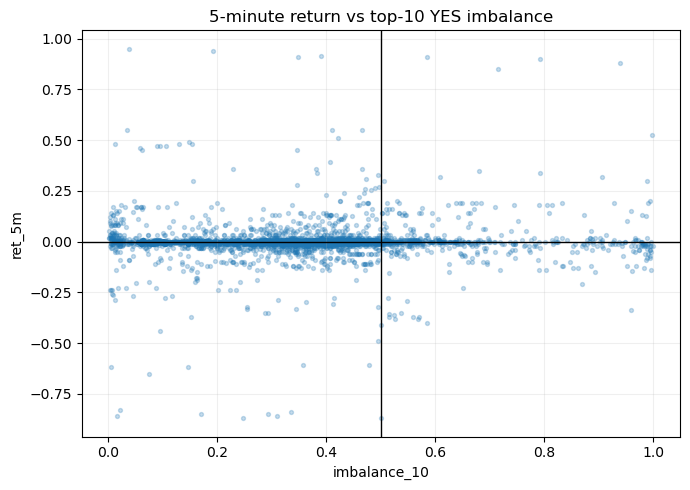

In [7]:
targets = ["ret_1m", "ret_5m", "ret_15m", "ret_30m", "ret_60m"]
feature_cols = [
    "imbalance_1", "imbalance_5", "imbalance_10", "excess_pressure_10",
    "lagged_mid_return_1m", "lagged_mid_return_5m", "spread", "spread_pct",
    "pressure_change_1m", "pressure_change_5m", "volume_1m", "volume_5m",
    "trade_count_1m", "aggressive_yes_share_1m", "time_to_close_minutes", "sum_mid_deviation_from_1"
]
cor = features[feature_cols + targets].corr(numeric_only=True).loc[feature_cols, targets].round(3)
display(cor)

bucket_rows = []
for col in ["imbalance_1", "imbalance_5", "imbalance_10", "excess_pressure_10"]:
    x = features.dropna(subset=[col, "ret_5m"]).copy()
    x["bucket"] = pd.qcut(x[col], 5, duplicates="drop")
    b = x.groupby("bucket", observed=True).agg(n=("ret_5m", "size"), avg_feature=(col, "mean"), avg_ret_5m=("ret_5m", "mean"), up_rate=("ret_5m", lambda s: (s > 0).mean()))
    b.insert(0, "feature", col)
    bucket_rows.append(b.reset_index(drop=True))
buckets = pd.concat(bucket_rows, ignore_index=True).round(4)
display(buckets)

fig, ax = plt.subplots(figsize=(7, 5))
x = features.dropna(subset=["imbalance_10", "ret_5m"])
ax.scatter(x["imbalance_10"], x["ret_5m"], s=8, alpha=.25)
ax.axhline(0, color="black", lw=1); ax.axvline(.5, color="black", lw=1)
ax.set_title("5-minute return vs top-10 YES imbalance")
ax.set_xlabel("imbalance_10"); ax.set_ylabel("ret_5m")
ax.grid(alpha=.2); fig.tight_layout(); fig.savefig(FIG / "imbalance_vs_ret5m.png", dpi=160); plt.show()

## 7. By-match stability

In [8]:
by_event_corr = []
for event, g in features.groupby("event"):
    row = {"event": event, "rows": len(g), "non_null_ret_5m": int(g["ret_5m"].notna().sum())}
    for col in ["imbalance_10", "excess_pressure_10", "volume_1m", "lagged_mid_return_1m"]:
        row[f"corr_{col}_ret_5m"] = g[[col, "ret_5m"]].corr().iloc[0,1]
    by_event_corr.append(row)
by_event_corr = pd.DataFrame(by_event_corr).round(3)
display(by_event_corr)

,event,rows,non_null_ret_5m,corr_imbalance_10_ret_5m,corr_excess_pressure_10_ret_5m,corr_volume_1m_ret_5m,corr_lagged_mid_return_1m_ret_5m
0,KXWCGAME-26JUN16ARGDZA,1971,1778,0.029,-0.099,0.035,-0.106
1,KXWCGAME-26JUN16IRQNOR,924,751,0.053,-0.030,-0.017,-0.172
2,KXWCGAME-26JUN17ENGCRO,228,96,-0.391,-0.501,-0.047,-0.287
3,KXWCGAME-26JUN17GHAPAN,414,354,0.105,0.200,0.015,-0.117
4,KXWCGAME-26JUN17PORCOD,777,729,0.132,0.064,NaN,0.127
5,KXWCGAME-26JUN17UZBCOL,423,316,0.139,0.138,-0.052,-0.115
6,KXWCGAME-26JUN18CZERSA,402,347,0.029,0.161,-0.025,0.223
7,KXWCGAME-26JUN18SUIBIH,381,258,-0.326,-0.182,0.022,0.045


## 8. Match narration overlay

Manual narration is sourced from FIFA match reports where available. Timestamps are approximate UTC overlays derived from reported match minute and kickoff, so use them for chart context, not millisecond event timing.

manual narration rows: 104 across 8 matches


event_type,fulltime,goal,halftime,match_start,own_goal,substitution,yellow_card
event_ticker,,,,,,,
KXWCGAME-26JUN16ARGDZA,1,3,0,1,0,5,0
KXWCGAME-26JUN16IRQNOR,1,4,0,1,1,2,1
KXWCGAME-26JUN17ENGCRO,1,6,0,1,0,5,0
KXWCGAME-26JUN17GHAPAN,1,1,0,1,0,7,3
KXWCGAME-26JUN17PORCOD,1,2,1,1,0,6,4
KXWCGAME-26JUN17UZBCOL,1,4,0,1,0,5,2
KXWCGAME-26JUN18CZERSA,1,2,0,1,0,6,3
KXWCGAME-26JUN18SUIBIH,1,5,0,1,0,6,4


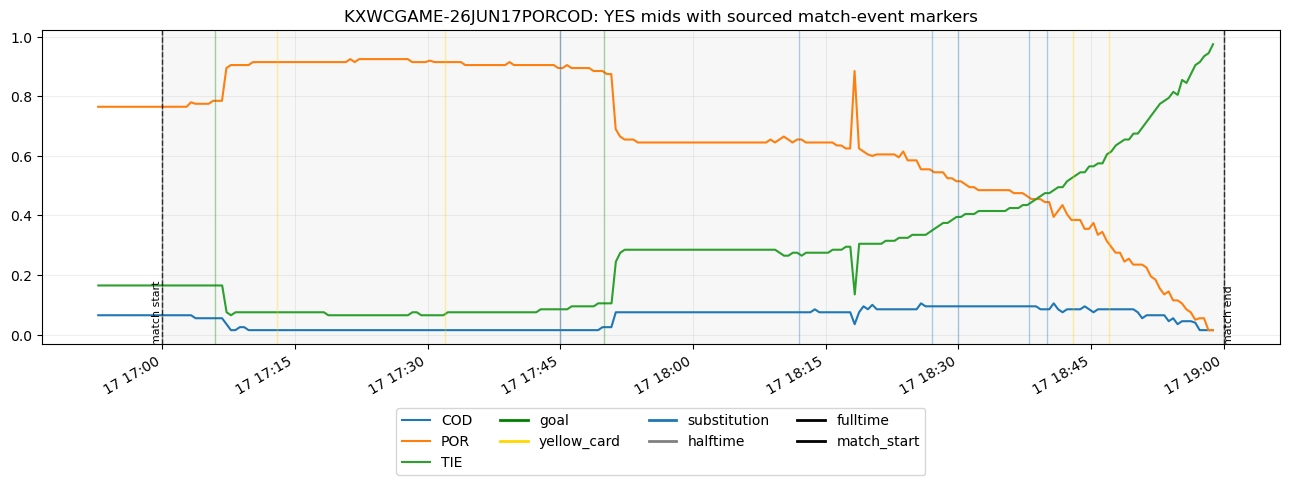

In [9]:
events_manual = load_manual_events()
print(f"manual narration rows: {len(events_manual)} across {events_manual['event_ticker'].nunique()} matches")
display(events_manual.groupby(["event_ticker", "event_type"]).size().unstack(fill_value=0))

for event, ev in events_manual.dropna(subset=["ts"]).groupby("event_ticker"):
    px = features[features["event"].eq(event)].sort_values("ts")
    if px.empty:
        continue
    ev = ev.sort_values("ts")
    fig, ax = plt.subplots(figsize=(13, 5))
    for outcome, g in px.groupby("outcome"):
        ax.plot(g["ts"], g["yes_mid"], label=outcome)
    for _, r in ev.iterrows():
        ax.axvline(r["ts"], color=EVENT_COLORS.get(r["event_type"], "gray"), alpha=.35, lw=1)
    mark_match_bounds(ax, event, events_manual)
    event_handles = [Line2D([0], [0], color=color, lw=2, label=typ) for typ, color in EVENT_COLORS.items() if typ in set(ev["event_type"])]
    price_handles, price_labels = ax.get_legend_handles_labels()
    ax.legend(price_handles + event_handles, price_labels + [h.get_label() for h in event_handles], ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.18))
    ax.set_title(f"{event}: YES mids with sourced match-event markers")
    ax.grid(alpha=.2)
    fig.autofmt_xdate(); fig.tight_layout()
    fig.savefig(FIG / f"narration_overlay_{event}.png", dpi=160, bbox_inches="tight")
    if event == "KXWCGAME-26JUN17PORCOD":
        plt.show()
    else:
        plt.close(fig)

In [10]:
def goal_latency_table(event="KXWCGAME-26JUN17PORCOD", window="3min"):
    ev = events_manual[(events_manual["event_ticker"].eq(event)) & (events_manual["event_type"].isin(["goal", "own_goal"]))].dropna(subset=["ts"])
    px = features[features["event"].eq(event)].sort_values(["outcome", "ts"])
    rows = []
    for _, goal in ev.iterrows():
        for outcome, g in px.groupby("outcome"):
            w = g[g["ts"].between(goal["ts"] - pd.Timedelta(minutes=2), goal["ts"] + pd.Timedelta(window))][["ts", "yes_mid"]].copy()
            w["step"] = w["yes_mid"].diff()
            post = w[w["ts"].ge(goal["ts"])]
            if post.empty or post["step"].abs().dropna().empty:
                continue
            jump = post.loc[post["step"].abs().idxmax()]
            before = w[w["ts"].lt(goal["ts"])].tail(1)
            rows.append({
                "goal_minute": goal["minute"],
                "goal_team": goal["team"],
                "outcome": outcome,
                "goal_ts_approx": goal["ts"],
                "pre_mid": np.nan if before.empty else before["yes_mid"].iloc[0],
                "largest_post_step_ts": jump["ts"],
                "latency_seconds_from_minute_stamp": (jump["ts"] - goal["ts"]).total_seconds(),
                "largest_post_step": jump["step"],
            })
    return pd.DataFrame(rows)

porcod_goal_latency = goal_latency_table()
display(porcod_goal_latency.round({"pre_mid": 3, "largest_post_step": 3, "latency_seconds_from_minute_stamp": 0}))
print("Interpretation: apparent 60-90s delays are measured from coarse FIFA match-minute timestamps, not exact goal timestamps. This does not verify exploitable latency.")

,goal_minute,goal_team,outcome,goal_ts_approx,pre_mid,largest_post_step_ts,latency_seconds_from_minute_stamp,largest_post_step
0,6,POR,COD,2026-06-17 17:06:00+00:00,0.055,2026-06-17 17:07:16.241446+00:00,76.0,-0.020
1,6,POR,POR,2026-06-17 17:06:00+00:00,0.785,2026-06-17 17:07:15.596857+00:00,76.0,0.110
2,6,POR,TIE,2026-06-17 17:06:00+00:00,0.165,2026-06-17 17:07:16.899675+00:00,77.0,-0.090
3,45+5,COD,COD,2026-06-17 17:50:00+00:00,0.025,2026-06-17 17:51:16.536673+00:00,77.0,0.050
4,45+5,COD,POR,2026-06-17 17:50:00+00:00,0.885,2026-06-17 17:51:15.934103+00:00,76.0,-0.185
5,45+5,COD,TIE,2026-06-17 17:50:00+00:00,0.105,2026-06-17 17:51:17.201444+00:00,77.0,0.140


Interpretation: apparent 60-90s delays are measured from coarse FIFA match-minute timestamps, not exact goal timestamps. This does not verify exploitable latency.


## 9. Summary

Use the tables above as first-pass evidence. A signal is only promising if it survives by-match checks and has sensible bucket behavior; otherwise it is a data-collection lead, not a trading strategy.